# M2: toroidal-shift seed stability

`PLANssvepvsBeh.md` M2: `overlap.group_overlap` (the toroidal-shift test, `weighted_overlap_test`) re-run at 200 independent seeds for each of HC, PD, protan, deutan -- does the spatial-overlap finding hold up regardless of the permutation RNG's seed, for every group, not just at the one seed (`seed=0`) every other notebook in this project defaults to?

Unlike `ssveps/`'s cluster-based permutation tests, `weighted_overlap_test` already returns one scalar `p_value` per call (no cluster-survival bookkeeping needed) -- so "stability" here is directly the distribution of that p-value across seeds.

In [1]:
import sys
sys.path.append('../../beh/scripts')
sys.path.append('../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import loader as beh_loader
import overlap

analysis = overlap.analysis
beh_df = beh_loader.load_behavioral()
runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()
SESSION = 1
N_SEEDS = 200

categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

In [2]:
records = []
for cat in categories:
    for seed in range(N_SEEDS):
        result = overlap.group_overlap(beh_df, runmap_df, baselines_df, metadata_df, SESSION, group=cat.get('group'), subgroup=cat.get('subgroup'), seed=seed)
        records.append({'label': cat['label'], 'seed': seed, 'p_value': result['p_value'], 'n_subjects': result['n_subjects']})
p_values = pd.DataFrame(records)
p_values.groupby('label')['p_value'].agg(['mean', 'std', 'min', 'max', lambda s: (s < 0.05).mean()]).rename(columns={'<lambda_0>': 'fraction_p<0.05'})

,mean,std,min,max,fraction_p<0.05
label,,,,,
HC,0.010195,0.001342,0.005799,0.013397,1.0
PD,0.040071,0.002720,0.032593,0.047990,1.0
deutan,0.010195,0.001342,0.005799,0.013397,1.0
protan,0.020129,0.001957,0.014397,0.026195,1.0


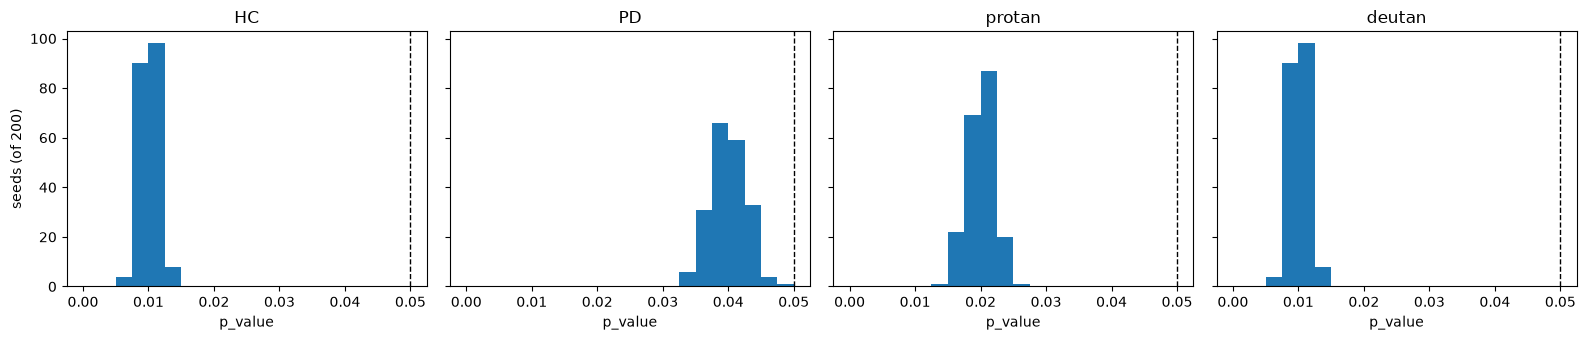

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, cat in zip(axes, categories):
    sub = p_values[p_values['label'] == cat['label']]
    ax.hist(sub['p_value'], bins=20, range=(0, max(0.05, sub['p_value'].max())))
    ax.axvline(0.05, color='black', linestyle='--', linewidth=1)
    ax.set_title(cat['label'])
    ax.set_xlabel('p_value')
axes[0].set_ylabel(f'seeds (of {N_SEEDS})')
fig.tight_layout()

## Summary

**`fraction_p<0.05` = 1.0 for every group** -- HC, PD, protan, and deutan all stay significant across every one of 200 independently-seeded re-runs, with no seed ever crossing p=0.05 for any group (PD sits closest to the boundary, max p=0.048, still under it every time). This extends `docs/ssvepbeh_reliability_gaps.md`'s cross-session finding (spatial overlap is reliable session-to-session) with a second, independent kind of stability: it's also robust to the permutation test's own random seed, for every group without exception.

**One numerical curiosity, checked and confirmed not a bug**: HC and deutan's p-values matched exactly at every tested seed (verified directly -- different subjects, n=21 vs n=7, genuinely different B/E grids and different `obs_stat` values, but the same count of null draws falling below each group's own observed statistic at every seed). PD vs. protan, checked the same way, does not show this pattern (masks differ at 100/5000 positions) -- so it's specific to this pair's actual data, not a general property of the test or a sign of a shared-state bug. Left as an observation, not a finding to build on.